# Functional Propagation

This notebook contains code to generate eggnog-mapper annotations and a GO Association File (GAF). This will then be used with HOGPROP to annotate the ancestral genomes in our mini dataset.

In [1]:
common_data_path = '/home/ubuntu/SIBBiodiversitySummerSchool2026Topic4/CommonData/Topic4CommonData'

In [2]:
from Bio import SeqIO
import os
import subprocess
import pandas as pd

## Run eggnog-mapper

Before we can perform functional enrichment analyses, we need functional annotations for our proteins. In this step, we will use eggNOG-mapper to assign functional annotations based on orthology relationships.

### Running eggNOG-mapper on a small example

For demonstration purposes, we will first run eggNOG-mapper on a small subset of proteins. We will after load the precomputed results on all proteomes.

In [3]:
input_fasta = os.path.join( common_data_path, "shared/proteomes", "Gallus_gallus.fa")
output_fasta = "test_10_proteins.fa"

records = []

for i, record in enumerate(SeqIO.parse(input_fasta, "fasta")):
    records.append(record)
    if i == 9:
        break

SeqIO.write(records, output_fasta, "fasta")

print(f"Wrote {len(records)} proteins")

Wrote 10 proteins


In [4]:
#Run eggNOG-mapper

EGGNOG_DATA_DIR = os.path.join( common_data_path, "Module4", "eggnog_db")


cmd = [
    "emapper.py",
    "-i", "test_10_proteins.fa",
    "--itype", "proteins",
    "-o", "test_annotation",
    "--data_dir", EGGNOG_DATA_DIR,
    "--tax_scope", "Vertebrata",
    "--cpu", "8",
    "--resume"
]

subprocess.run(cmd, check=True)

#  emapper-2.1.13-fac3438
# emapper.py  -i test_10_proteins.fa --itype proteins -o test_annotation --data_dir /home/ubuntu/SIBBiodiversitySummerSchool2026Topic4/CommonData/Topic4CommonData/Module4/eggnog_db --tax_scope Vertebrata --cpu 8 --resume


Functional annotation of hits...


Done
Result files:
   /home/ubuntu/SIBBiodiversitySummerSchool2026Topic4/Module4_FunctionalAnalysis/step1_annotation/test_annotation.emapper.hits
   /home/ubuntu/SIBBiodiversitySummerSchool2026Topic4/Module4_FunctionalAnalysis/step1_annotation/test_annotation.emapper.seed_orthologs
   /home/ubuntu/SIBBiodiversitySummerSchool2026Topic4/Module4_FunctionalAnalysis/step1_annotation/test_annotation.emapper.annotations

CITATION:
If you use this software, please cite:

[1] eggNOG-mapper v2: functional annotation, orthology assignments, and domain 
      prediction at the metagenomic scale. Carlos P. Cantalapiedra, 
      Ana Hernandez-Plaza, Ivica Letunic, Peer Bork, Jaime Huerta-Cepas. 2021.
      Molecular Biology and Evolution, msab293, https://doi.org/10.1093/molbev/msab293

[2] eggNOG 5.0: a hierarchical, functionally and phylogenetically annotated
      orthology resource based on 5090 organisms and 2502 viruses. Jaime
      Huerta-Cepas, Damian Szklarczyk, Davide Heller, Ana Hernandez

10 0.23520231246948242 42.52 q/s (% mem usage: 6.40, % mem avail: 93.63)


CompletedProcess(args=['emapper.py', '-i', 'test_10_proteins.fa', '--itype', 'proteins', '-o', 'test_annotation', '--data_dir', '/home/ubuntu/SIBBiodiversitySummerSchool2026Topic4/CommonData/Topic4CommonData/Module4/eggnog_db', '--tax_scope', 'Vertebrata', '--cpu', '8', '--resume'], returncode=0)

Let's read in eggnog-mapper annotations file for the 10 proteins that you just created:

In [5]:
#examine results

columns = ['#query', 'seed_ortholog', 'evalue', 'score', 'eggNOG_OGs',
           'max_annot_lvl', 'COG_category', 'Description', 'Preferred_name', 'GOs',
           'EC', 'KEGG_ko', 'KEGG_Pathway', 'KEGG_Module', 'KEGG_Reaction',
           'KEGG_rclass', 'BRITE', 'KEGG_TC', 'CAZy', 'BiGG_Reaction', 'PFAMs']

test_df = pd.read_csv(
    "test_annotation.emapper.annotations",
    sep="\t",
    comment="#",
    header=None,
    names=columns
)

test_df

,#query,seed_ortholog,evalue,score,eggNOG_OGs,max_annot_lvl,COG_category,Description,Preferred_name,GOs,...,KEGG_ko,KEGG_Pathway,KEGG_Module,KEGG_Reaction,KEGG_rclass,BRITE,KEGG_TC,CAZy,BiGG_Reaction,PFAMs
0,GALGAL_R08064,9031.ENSGALP00000000002,0.000000e+00,1319.0,"28KPB@1|root,2QT63@2759|Eukaryota,38EQ0@33154|...",7742|Vertebrata,S,Innexin,PANX2,"GO:0002931,GO:0003674,GO:0005215,GO:0005243,GO...",...,ko:K20857,-,-,-,-,"ko00000,ko02000","1.A.25.2.2,1.A.25.2.3",-,-,Innexin
1,GALGAL_R08065,9031.ENSGALP00000000795,4.950000e-93,272.0,"KOG2032@1|root,KOG2032@2759|Eukaryota,3APXZ@33...",7742|Vertebrata,S,maestro heat-like repeat-containing protein fa...,-,-,...,-,-,-,-,-,-,-,-,-,-
2,GALGAL_R08066,9031.ENSGALP00000035827,3.620000e-88,275.0,"KOG2032@1|root,KOG2032@2759|Eukaryota,39XJ0@33...",7742|Vertebrata,S,family member 2A,MROH2A,-,...,-,-,-,-,-,-,-,-,-,-
3,GALGAL_R08067,9031.ENSGALP00000035827,1.070000e-83,264.0,"KOG2032@1|root,KOG2032@2759|Eukaryota,39XJ0@33...",7742|Vertebrata,S,family member 2A,MROH2A,-,...,-,-,-,-,-,-,-,-,-,-
4,GALGAL_R08068,9031.ENSGALP00000035827,1.370000e-84,266.0,"KOG2032@1|root,KOG2032@2759|Eukaryota,39XJ0@33...",7742|Vertebrata,S,family member 2A,MROH2A,-,...,-,-,-,-,-,-,-,-,-,-
5,GALGAL_R08069,9031.ENSGALP00000001227,0.000000e+00,1756.0,"2CN6C@1|root,2QU3U@2759|Eukaryota,38GGN@33154|...",7742|Vertebrata,S,52 kDa repressor of the inhibitor of the prote...,PRKRIR,"GO:0000981,GO:0003674,GO:0003676,GO:0003677,GO...",...,-,-,-,-,-,-,-,-,-,"DUF4371,Dimer_Tnp_hAT,THAP"
6,GALGAL_R08070,128390.XP_009474752.1,2.340000e-267,730.0,"KOG3913@1|root,KOG3913@2759|Eukaryota,38SE0@33...",7742|Vertebrata,T,Ligand for members of the frizzled family of s...,WNT11,"GO:0001067,GO:0001101,GO:0001501,GO:0001503,GO...",...,ko:K01384,"ko04150,ko04310,ko04390,ko04550,ko04916,ko0493...",M00677,-,-,"ko00000,ko00001,ko00002,ko00536",-,-,-,wnt
7,GALGAL_R08071,181119.XP_005526606.1,5.740000e-61,191.0,"KOG4023@1|root,KOG4023@2759|Eukaryota,39ZSQ@33...",7742|Vertebrata,S,SH3 domain-binding glutamic acid-rich protein,SH3BGR,"GO:0003674,GO:0005070,GO:0005488,GO:0005515,GO...",...,ko:K22384,-,-,-,-,"ko00000,ko02000","3.A.19,3.A.21",-,-,SH3BGR
8,GALGAL_R08072,9031.ENSGALP00000027083,2.720000e-71,238.0,"COG5171@1|root,KOG0864@2759|Eukaryota,38EUB@33...",7742|Vertebrata,O,Ran-binding domain,RANBP2,"GO:0000082,GO:0000226,GO:0000278,GO:0003674,GO...",...,ko:K12172,"ko03013,map03013",M00427,-,-,"ko00000,ko00001,ko00002,ko03019,ko03110,ko04121",-,-,-,"IR1-M,Pro_isomerase,Ran_BP1,zf-RanBP"
9,GALGAL_R08073,9031.ENSGALP00000005392,0.000000e+00,1783.0,"KOG3695@1|root,KOG3695@2759|Eukaryota,38C7C@33...",7742|Vertebrata,S,Family with sequence similarity 160 member A2,FAM160A2,"GO:0005575,GO:0005622,GO:0005623,GO:0005737,GO...",...,-,-,-,-,-,-,-,-,-,RAI16-like


**In this example, how many proteins have go annotations? What are their descriptions?**

Try it yourself before expanding the solution below.

<details>
<summary><b>Click to reveal solution</b></summary>

```python
print("Proteins with GO annotations: ", len(test_df[test_df["GOs"] != "-"]))
test_df[test_df["GOs"] != "-"][['#query', 'Preferred_name', 'Description']]

In [ ]:
print("Proteins with GO annotations: ", len(test_df[test_df["GOs"] != "-"]))
test_df[test_df["GOs"] != "-"][['#query', 'Preferred_name', 'Description']]

Proteins with GO annotations:  6


,#query,Preferred_name,Description
0,GALGAL_R08064,PANX2,Innexin
5,GALGAL_R08069,PRKRIR,52 kDa repressor of the inhibitor of the prote...
6,GALGAL_R08070,WNT11,Ligand for members of the frizzled family of s...
7,GALGAL_R08071,SH3BGR,SH3 domain-binding glutamic acid-rich protein
8,GALGAL_R08072,RANBP2,Ran-binding domain
9,GALGAL_R08073,FAM160A2,Family with sequence similarity 160 member A2


### Running eggNOG-mapper on the whole dataset

**Attention: In the interest of time, skip this part about running eggnog-mapper using a HPC. Instead, go to the next section ('Read eggnog-mapper results') to load precomputed results from the whole dataset.**


Now that we have explored the eggNOG-mapper command and its output files, we can scale up the analysis to all proteomes in our dataset.

Open the provided `eggnog.sh` script and review the input, output, and database paths. Modify them if needed for your setup.

Submit the job array:

`sbatch eggnog.sh`

Monitor the jobs with:

`squeue -u $USER`

Once the jobs have completed, inspect the annotation results in the results/ directory.

## Read eggnog-mapper results

The `.emapper.annotations` files produced by eggNOG-mapper contain functional annotations for each protein, including Gene Ontology (GO) terms. In this section, we will load these files into pandas dataframes and extract the GO annotations needed for the next step of the workflow.

In [6]:
from Bio.UniProt.GOA import GAF20FIELDS
from datetime import datetime
from hogprop.OBOParser import OBO

First we need to get the Gene Ontology (GO) definition file, in <a href="https://owlcollab.github.io/oboformat/doc/GO.format.obo-1_2.html">OBO</a> format. It is pre-downloaded for this course and found in the CommonData. This is the same file that can be found here: https://current.geneontology.org/ontology/go-basic.obo. 

Then we can load using the OBO parser within the hogprop tool. We will use this later in this notebook.

In [7]:
go = OBO(os.path.join(common_data_path, 'Module4', 'go-basic.obo') , store_as_int=True)

Here are the headers of the columns for the eggnog-mapper 'annotation' files:

In [8]:
eggnog_mapper_header = ['query',
 'seed_ortholog',
 'evalue',
 'score',
 'eggNOG_OGs',
 'max_annot_lvl',
 'COG_category',
 'Description',
 'Preferred_name',
 'GOs',
 'EC',
 'KEGG_ko',
 'KEGG_Pathway',
 'KEGG_Module',
 'KEGG_Reaction',
 'KEGG_rclass',
 'BRITE',
 'KEGG_TC',
 'CAZy',
 'BiGG_Reaction',
 'PFAMs']

Get a list of the species:

In [9]:
#using precomputed results
eggnog_mapper_results_path = os.path.join(common_data_path, 'Module4', 'precomputed_results' ,'eggnog')
species = set(map(lambda x: x.split('.')[0], os.listdir(eggnog_mapper_results_path)))
species

{'Aptenodytes_forsteri',
 'Columba_livia',
 'Crocodylus_porosus',
 'Gallus_gallus',
 'Grus_americana',
 'Homo_sapiens',
 'Oreotrochilus_melanogaster',
 'Phoenicopterus_ruber',
 'Struthio_camelus',
 'Taeniopygia_guttata'}

Function to load a single file:

In [10]:
def read_single_eggnog_mapper_results(sp, results_path):
    fn = os.path.join(results_path, sp + '.emapper.annotations')
    if os.path.isfile(fn):
        df = pd.read_csv(fn, sep='\t', comment='#', names=eggnog_mapper_header)
        return df[['query', 'GOs']]
    else:
        return None

Then we want to load all into a single dataframe

In [11]:
dfs = []
for sp in species:
    df = read_single_eggnog_mapper_results(sp, eggnog_mapper_results_path)
    df['species'] = sp
    if df is not None:  # this can be removed if all exist!
        dfs.append(df)

df = pd.concat(dfs)

Take a look at the dataframe:

In [12]:
df.head()

,query,GOs,species
0,ENSP00000451578.1,-,Homo_sapiens
1,ENSP00000451750.1,-,Homo_sapiens
2,ENSP00000374915.3,-,Homo_sapiens
3,ENSP00000488969.1,-,Homo_sapiens
4,ENSP00000489072.1,-,Homo_sapiens


Now we can remove proteins with no GO terms predicted:

In [13]:
df = df[df.GOs != '-']

In [14]:
df.head()

,query,GOs,species
166,ENSP00000487609.1,"GO:0003674,GO:0005102,GO:0005488,GO:0005515,GO...",Homo_sapiens
167,ENSP00000417505.1,"GO:0002250,GO:0002252,GO:0002253,GO:0002376,GO...",Homo_sapiens
170,ENSP00000418818.1,"GO:0002250,GO:0002252,GO:0002253,GO:0002376,GO...",Homo_sapiens
171,ENSP00000419223.1,"GO:0003674,GO:0005102,GO:0005488,GO:0005515,GO...",Homo_sapiens
175,ENSP00000487823.1,"GO:0002250,GO:0002252,GO:0002253,GO:0002376,GO...",Homo_sapiens


Now we have loaded a table containing protein ids and a list of GO terms that eggNOG-mapper has predicted. We now want to convert this into a long format.

In [15]:
from tqdm import tqdm

def convert_long(df, prot_key, go_key, sep):
    def do():
        for (_, r) in tqdm(df.iterrows(), total=len(df)):
            for t in r[go_key].split(sep):
                yield (r[prot_key], t, r['species'])
    return pd.DataFrame(do(), columns=['prot_id', 'go_id', 'species'])

# convert to long form (i.e., one protein ID, one GO term per row)
df = convert_long(df, prot_key='query', go_key='GOs', sep=',')

# add source information to the dataframe
df['source'] = 'eggnog-mapper'

100%|██████████| 226025/226025 [01:51<00:00, 2033.55it/s]


In [16]:
df.head()

,prot_id,go_id,species,source
0,ENSP00000487609.1,GO:0003674,Homo_sapiens,eggnog-mapper
1,ENSP00000487609.1,GO:0005102,Homo_sapiens,eggnog-mapper
2,ENSP00000487609.1,GO:0005488,Homo_sapiens,eggnog-mapper
3,ENSP00000487609.1,GO:0005515,Homo_sapiens,eggnog-mapper
4,ENSP00000487609.1,GO:0005575,Homo_sapiens,eggnog-mapper


GO prediction tools predict function associations based on the GO definition at a particular point in time. As we are using the most recent definition file (downloaded above), some terms used in the eggNOG-mapper predictions may now be obsolete.

In [17]:
all_go_terms = set(df.go_id)
obsolete_terms = set()
for t in all_go_terms:
    if t not in go:
        obsolete_terms.add(t)

print('found', len(obsolete_terms), 'obsolete terms in predictions')

found 2335 obsolete terms in predictions


We now want to remove any predictions to these terms from our dataframe:

In [18]:
f = df.go_id.isin(obsolete_terms)
df = df[~f]

Now we want to convert this into a <a href="https://geneontology.org/docs/go-annotation-file-gaf-format-2.2/">Gene Association File (GAF)</a> formatted file.

In [19]:
df["DB"] = df['source']
df["DB_Object_ID"] = df['prot_id']
# 3R DB Object Symbol
df["DB_Object_Symbol"] = df["DB_Object_ID"]
# 4O Qualifier
df["Qualifier"] = ""
# 5R GO ID
#df["GO_ID"] = df["TermNr"].apply(lambda t: "GO:{:07d}".format(t))
df['GO_ID'] = df['go_id']
# 6R DB:Reference
df["DB:Reference"] = df['source']
# 7R Evidence code
df["Evidence"] = "IEA"
# 8O With (or) From
df["With"] = ""
# 9R Aspect
df["Aspect"] = df["GO_ID"].apply(lambda t: go[t].aspect)
# 10O DB Object Name
df["DB_Object_Name"] = ""
# 11O DB Object Synonym (|Synonym)
df["Synonym"] = ""
# 12R DB Object Type
df["DB_Object_Type"] = "protein"
# 13R Taxon (|taxon)
df["Taxon_ID"] = 'Viridiplantae'
# 14R Date
df["Date"] = str(datetime.now()).split(' ')[0]
# 15R Assigned by
df["Assigned_By"] = df["DB"]
# 16O Annotation Extension
df["Annotation_Extension"] = ""
# 17O Gene Product Form ID
df["Gene_Product_Form_ID"] = ""

In [20]:
gaf_df = df[GAF20FIELDS]

Now save the GAF file with the code below.

In [21]:
import gzip

with gzip.open('extant_predictions.gaf.gz', 'wt') as fp:
    print('!gaf-version: 2.0', file=fp)
    gaf_df.to_csv(fp, sep='\t', index=False, header=False)

## Questions
1. How many annotations were there in total made by eggnog-mapper?
2. How many proteins received at least one GO annotation in each species?
3. Which species has the highest annotation coverage?
4. Which GO namespace (Biological Process, Molecular Function, Cellular Component) contains the most annotations?
5. How many unique GO terms are present in the combined dataset?
6. Which GO terms are most frequently observed?

**1. How many annotations were there in total made by eggnog-mapper?**

In [22]:
len(df)

23503224

**2. How many proteins received at least one GO annotation in each species?**


<details>
<summary>Solution</summary>

```python
df.groupby('species').size().reset_index(name='count')

```
</details> 

In [23]:
#number of go annotations per species
df.groupby('species').size().reset_index(name='count')

,species,count
0,Aptenodytes_forsteri,1163682
1,Columba_livia,1182700
2,Crocodylus_porosus,2261179
3,Gallus_gallus,1234802
4,Grus_americana,1178224
5,Homo_sapiens,11859602
6,Oreotrochilus_melanogaster,1089984
7,Phoenicopterus_ruber,1027147
8,Struthio_camelus,1103613
9,Taeniopygia_guttata,1402291


Why are there more GO annotations for human?

Human and crocodile contain multiple protein isoforms per gene. To make annotation coverage comparable across species, we restrict the analysis to the representative isoforms defined in the splice files.

In [24]:
main_isoforms = {}

for species in ["Homo_sapiens", "Crocodylus_porosus"]:
    
    splice_path = os.path.join(
        common_data_path, 'Module2','in_folder', 'splice',
        f"{species}.splice"
    )

    with open(splice_path) as f:
        for line in f:
            proteins = line.strip().split(";")
    
            if proteins:
                main_isoforms[proteins[0]] = species

len(main_isoforms)

39063

In [25]:
from collections import Counter

species_counts = Counter(main_isoforms.values())

species_counts

Counter({'Homo_sapiens': 23837, 'Crocodylus_porosus': 15226})

In [26]:
human_croc = df["species"].isin(
    ["Homo_sapiens", "Crocodylus_porosus"]
)

keep = (
    ~human_croc | df["prot_id"].isin(main_isoforms)
)

df_filtered = df[keep].copy()

In [29]:
df_filtered[
    df_filtered["species"] == "Homo_sapiens"
]["prot_id"].nunique()

20019

### 2. How many proteins received at least one GO annotation in each species?

In [30]:
#number of genes with at least 1 go annotations per species
coverage_df = df_filtered.drop_duplicates('prot_id').groupby('species').size().reset_index(name='count')
coverage_df

,species,count
0,Aptenodytes_forsteri,11874
1,Columba_livia,12006
2,Crocodylus_porosus,11707
3,Gallus_gallus,12775
4,Grus_americana,11974
5,Homo_sapiens,20019
6,Oreotrochilus_melanogaster,11021
7,Phoenicopterus_ruber,10502
8,Struthio_camelus,11284
9,Taeniopygia_guttata,13999


### 3. Which species has the highest annotation coverage?

i.e. What percentage of proteins in each species has at least 1 GO annotation?

In [31]:
from collections import Counter
from Bio import SeqIO
from pathlib import Path

# Counts from the main_isoforms dictionary
species_counts = Counter(main_isoforms.values())

# Add counts from FASTA files for species not already present
for fasta in Path(common_data_path ,"shared", "proteomes").glob("*.fa*"):

    species = fasta.stem
    print(species)

    if species not in species_counts:

        n_proteins = sum(
            1 for _ in SeqIO.parse(fasta, "fasta")
        )

        species_counts[species] = n_proteins

print(species_counts)


Taeniopygia_guttata
Crocodylus_porosus
Oreotrochilus_melanogaster
Phoenicopterus_ruber
Columba_livia
Grus_americana
Struthio_camelus
Homo_sapiens
Aptenodytes_forsteri
Gallus_gallus
Elachura_formosa_1463973
Counter({'Homo_sapiens': 23837, 'Taeniopygia_guttata': 19174, 'Gallus_gallus': 17883, 'Elachura_formosa_1463973': 15723, 'Columba_livia': 15666, 'Grus_americana': 15511, 'Aptenodytes_forsteri': 15378, 'Crocodylus_porosus': 15226, 'Struthio_camelus': 14566, 'Oreotrochilus_melanogaster': 13940, 'Phoenicopterus_ruber': 13508})


In [32]:
coverage_df["n_proteins"] = coverage_df["species"].map(species_counts)

coverage_df["percent_annotated"] = (
    100 * coverage_df["count"] / coverage_df["n_proteins"]
)

coverage_df

,species,count,n_proteins,percent_annotated
0,Aptenodytes_forsteri,11874,15378,77.214202
1,Columba_livia,12006,15666,76.637304
2,Crocodylus_porosus,11707,15226,76.888218
3,Gallus_gallus,12775,17883,71.436560
4,Grus_americana,11974,15511,77.196828
5,Homo_sapiens,20019,23837,83.982884
6,Oreotrochilus_melanogaster,11021,13940,79.060258
7,Phoenicopterus_ruber,10502,13508,77.746521
8,Struthio_camelus,11284,14566,77.468076
9,Taeniopygia_guttata,13999,19174,73.010326


### 4. Which GO namespace (Biological Process, Molecular Function, Cellular Component) contains the most annotations?


In [33]:
#Which GO namespace (Biological Process, Molecular Function, Cellular Component)
#contains the most annotations?

aspect_map = {
    "P": "Biological Process",
    "F": "Molecular Function",
    "C": "Cellular Component"
}

df_filtered["namespace"] = (
    df_filtered["go_id"]
      .apply(lambda x: aspect_map[go[x].aspect])
)

In [34]:
namespace_counts = (
    df_filtered.groupby("namespace")
      .size()
      .reset_index(name="n_annotations")
      .sort_values("n_annotations", ascending=False)
)

namespace_counts

,namespace,n_annotations
0,Biological Process,8822052
1,Cellular Component,2159603
2,Molecular Function,1429575


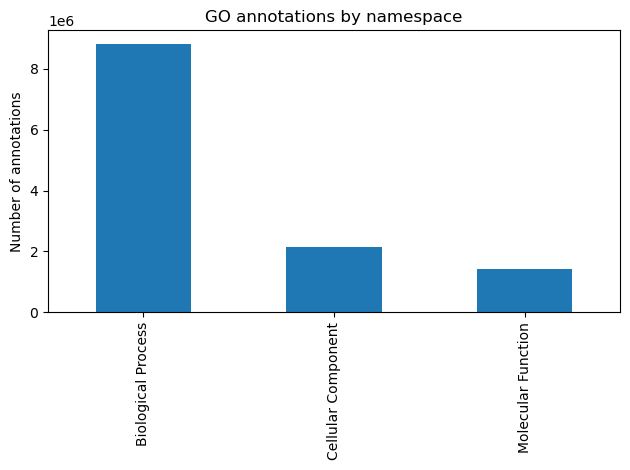

In [35]:
import matplotlib.pyplot as plt

namespace_counts.plot(
    x="namespace",
    y="n_annotations",
    kind="bar",
    legend=False
)

plt.ylabel("Number of annotations")
plt.xlabel("")
plt.title("GO annotations by namespace")
plt.tight_layout()
plt.show()

### 5. How many unique GO terms are present in the combined dataset?


In [36]:
df_filtered.groupby("namespace")["go_id"].nunique()

namespace
Biological Process    14305
Cellular Component     1811
Molecular Function     4251
Name: go_id, dtype: int64

In [37]:
#How many unique GO terms are present in the combined dataset?
df_filtered['GO_ID'].nunique()

20367

### 6. Which GO terms are most frequently observed?

In [38]:
# Which GO terms are most frequently observed?

tmp_df = df_filtered.groupby('GO_ID').size().\
reset_index(name='count').\
sort_values(by='count', ascending=False)[:10]
tmp_df['GO_name'] = tmp_df['GO_ID'].apply(lambda x: go[x].name)
tmp_df

,GO_ID,count,GO_name
2583,GO:0005575,120739,cellular_component
3790,GO:0008150,119421,biological_process
2614,GO:0005622,103729,intracellular anatomical structure
4495,GO:0009987,103486,cellular process
1567,GO:0003674,102238,molecular_function
10514,GO:0043226,90979,organelle
10517,GO:0043229,88966,intracellular organelle
14512,GO:0065007,86603,biological regulation
2665,GO:0005737,85192,cytoplasm
10515,GO:0043227,82426,membrane-bounded organelle
